## Sensitivity of Large-Scale Advections in the Trade-Wind Cumulus Model
- This Jupyter Notebook uses re-analysis datasets (ERA5) to investigate the large-scale terms in the diagnostic model.
- This code can be run at https://jupyter-hpc.ceoas.oregonstate.edu/

### Python packages
-  `research` environment has the required packages.
- I use miniconda. To install missing packages:
    - conda activate myenv
    - conda install -c conda-forge [package name (e.g., xarray)]
- To increase calculation efficiency, I also use joblib to do parallel calculation with 30 CPUs on this node (chen): https://joblib.readthedocs.io/en/stable/index.html#

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import dask
import pandas as pd
import re

from smooth import *
from pathlib import Path
from joblib import Memory, Parallel, delayed
from datetime import datetime

### Functions

In [2]:
def decode_files_time(name: str):
    # ERA5 u & v files
    m = re.search(rf".*\.(\d{{10}})_(\d{{10}})\.nc$", name, re.IGNORECASE)
    if m:
        fstart = datetime.strptime(m.group(1), "%Y%m%d%H")
        fend = datetime.strptime(m.group(2), "%Y%m%d%H")
        return fstart, fend
    return None

def find_filenames(directory, keyword, qstart, qend):
    fdir = Path(directory)
    files = []
    for fn in fdir.rglob("*"):
        if not fn.is_file():
            continue
        
        # Keyword used to filter file names
        fname = fn.name
        if keyword == "133_q" and "133_q" not in fname:
            continue
        if keyword == "130_t" and "130_t" not in fname:
            continue
        if keyword == "131_u" and "131_u" not in fname:
            continue
        if keyword == "132_v" and "132_v" not in fname:
            continue
        if keyword == "135_w" and "135_w" not in fname:
            continue
        if keyword == "129_z" and "129_z" not in fname:
            continue

        # Finding correct files
        ftime = decode_files_time(fn.name)
        if ftime is None:
            continue
        fstart, fend = ftime
        if fstart <= qend and fend >= qstart:
            files.append(fn)
    return sorted(files)

def parallel_worker(file, region_bound, var, spatialavg=False, timesample=False, spacesample=False):
    # Region bound
    lonmin, lonmax = region_bound[0], region_bound[1] # degrees East
    latmin, latmax = region_bound[2], region_bound[3] # degrees North
    levmin, levmax = region_bound[4], region_bound[5] # hPa
    
    ds = xr.open_dataset(file)
    
    try:
        # ---- NEW: keep only 0,3,6,9,12,15,18,21 UTC ----
        if timesample:
            ds = ds.sel(time=ds.time.dt.hour.isin([0, 3, 6, 9, 12, 15, 18, 21]))
            # ds = ds.sel(time=ds.time.dt.hour.isin([0, 2, 4, 6, 8, 10, 12 ,14, 16, 18, 20, 22]))

        varin = ds[var].sel(longitude=slice(lonmin, lonmax),
                            latitude=slice(latmax, latmin),
                            level=slice(levmin, levmax))

        if spacesample:
            varin = varin.isel(longitude=slice(None, None, 2), latitude=slice(None, None, 2))

        if spatialavg:
            weights = np.cos(np.radians(ds.latitude))
            varavg  = varin.weighted(weights).mean(dim=("longitude", "latitude")).squeeze()
        else:
            varavg = varin

        return varavg.values

    finally:
        ds.close()


def parallel_worker_advq(qfile, ufile, vfile, region_bound, qname="Q", uname="U", vname="V", spatialavg=False, timesample=False, spacesample=False):
    # Region bound
    lonmin, lonmax = region_bound[0], region_bound[1] # degrees East
    latmin, latmax = region_bound[2], region_bound[3] # degrees North
    levmin, levmax = region_bound[4], region_bound[5] # hPa

    R = 6371000.0  # Earth radius (m)

    dsq = xr.open_dataset(qfile)
    dsu = xr.open_dataset(ufile)
    dsv = xr.open_dataset(vfile)
    
    try:
        # ---- NEW: keep only 0,3,6,9,12,15,18,21 UTC ----
        if timesample:
            dsq = dsq.sel(time=dsq.time.dt.hour.isin([0, 3, 6, 9, 12, 15, 18, 21]))
            dsu = dsu.sel(time=dsu.time.dt.hour.isin([0, 3, 6, 9, 12, 15, 18, 21]))
            dsv = dsv.sel(time=dsv.time.dt.hour.isin([0, 3, 6, 9, 12, 15, 18, 21]))
            # dsq = dsq.sel(time=dsq.time.dt.hour.isin([0, 2, 4, 6, 8, 10, 12 ,14, 16, 18, 20, 22]))
            # dsu = dsu.sel(time=dsu.time.dt.hour.isin([0, 2, 4, 6, 8, 10, 12 ,14, 16, 18, 20, 22]))
            # dsv = dsv.sel(time=dsv.time.dt.hour.isin([0, 2, 4, 6, 8, 10, 12 ,14, 16, 18, 20, 22]))
        
        # subset (keep latitude slice in the same direction you used)
        qin = dsq[qname].sel(longitude=slice(lonmin, lonmax),
                            latitude=slice(latmax, latmin),
                            level=slice(levmin, levmax))
        uin = dsu[uname].sel(longitude=slice(lonmin, lonmax),
                            latitude=slice(latmax, latmin),
                            level=slice(levmin, levmax))
        vin = dsv[vname].sel(longitude=slice(lonmin, lonmax),
                            latitude=slice(latmax, latmin),
                            level=slice(levmin, levmax))

        if spacesample:
            qin = qin.isel(longitude=slice(None, None, 2), latitude=slice(None, None, 2))
            uin = uin.isel(longitude=slice(None, None, 2), latitude=slice(None, None, 2))
            vin = vin.isel(longitude=slice(None, None, 2), latitude=slice(None, None, 2))

        # coords
        lat_rad = np.deg2rad(qin.latitude.values)   # (nlat,)
        lon_rad = np.deg2rad(qin.longitude.values)  # (nlon,)

        # grid spacing (meters)
        dlat = np.gradient(lat_rad)                 # (nlat,) radians
        dlon = np.gradient(lon_rad)                 # (nlon,) radians
        dy   = R * dlat                              # (nlat,) meters
        dx   = R * np.cos(lat_rad)[:, None] * dlon[None, :]  # (nlat, nlon) meters

        # numpy arrays: (time, level, lat, lon)
        q = qin.values
        u = uin.values
        v = vin.values

        # gradients (per meter)
        dq_dy = np.gradient(q, axis=-2) / dy[None, None, :, None]
        dq_dx = np.gradient(q, axis=-1) / dx[None, None, :, :]

        adv_q = -(u * dq_dx + v * dq_dy)  # kg/kg/s

        # area-weighted mean over lat/lon (cos(lat) weights)
        if spatialavg:
            wlat = np.cos(lat_rad)[:, None]                 # (nlat, 1)
            w2d  = np.broadcast_to(wlat, dx.shape)          # (nlat, nlon)
            num  = np.nansum(adv_q * w2d[None, None, :, :], axis=(-2, -1))
            den  = np.nansum(w2d)
            adv_q_avg = (num / den)                         # (time, level)
        else:
            adv_q_avg = adv_q

        return adv_q_avg

    finally:
        dsq.close()
        dsu.close()
        dsv.close()

In [3]:
# DON'T rewrite parallel workers with hdf5 flag and with blocks

# def parallel_worker_advq(qfile, ufile, vfile, region_bound, qname="Q", uname="U", vname="V", spatialavg=False, timesample=False, spacesample=False):
#     # Region bound
#     lonmin, lonmax = region_bound[0], region_bound[1] # degrees East
#     latmin, latmax = region_bound[2], region_bound[3] # degrees North
#     levmin, levmax = region_bound[4], region_bound[5] # hPa
#     R = 6371000.0  # Earth radius (m)

#     # 1. Safely open all three datasets using context managers
#     with xr.open_dataset(qfile, engine="h5netcdf", decode_coords="lazy") as dsq, \
#          xr.open_dataset(ufile, engine="h5netcdf", decode_coords="lazy") as dsu, \
#          xr.open_dataset(vfile, engine="h5netcdf", decode_coords="lazy") as dsv:
        
#         # ---- time sampling ----
#         if timesample:
#             target_hours = [0, 3, 6, 9, 12, 15, 18, 21]
#             dsq = dsq.sel(time=dsq.time.dt.hour.isin(target_hours))
#             dsu = dsu.sel(time=dsu.time.dt.hour.isin(target_hours))
#             dsv = dsv.sel(time=dsv.time.dt.hour.isin(target_hours))

#         # ---- spatial subsetting ----
#         qin = dsq[qname].sel(longitude=slice(lonmin, lonmax), latitude=slice(latmax, latmin), level=slice(levmin, levmax))
#         uin = dsu[uname].sel(longitude=slice(lonmin, lonmax), latitude=slice(latmax, latmin), level=slice(levmin, levmax))
#         vin = dsv[vname].sel(longitude=slice(lonmin, lonmax), latitude=slice(latmax, latmin), level=slice(levmin, levmax))

#         if spacesample:
#             qin = qin.isel(longitude=slice(None, None, 2), latitude=slice(None, None, 2))
#             uin = uin.isel(longitude=slice(None, None, 2), latitude=slice(None, None, 2))
#             vin = vin.isel(longitude=slice(None, None, 2), latitude=slice(None, None, 2))

#         # coords
#         lat_rad = np.deg2rad(qin.latitude.values)
#         lon_rad = np.deg2rad(qin.longitude.values)

#         # grid spacing (meters)
#         dlat = np.gradient(lat_rad)
#         dlon = np.gradient(lon_rad)
#         dy = R * dlat
#         dx = R * np.cos(lat_rad)[:, None] * dlon[None, :]

#         # numpy arrays: (time, level, lat, lon)
#         q = qin.values
#         u = uin.values
#         v = vin.values

#         # gradients (per meter)
#         dq_dy = np.gradient(q, axis=-2) / dy[None, None, :, None]
#         dq_dx = np.gradient(q, axis=-1) / dx[None, None, :, :]
#         adv_q = -(u * dq_dx + v * dq_dy)

#         # area-weighted mean over lat/lon
#         if spatialavg:
#             wlat = np.cos(lat_rad)[:, None]
#             w2d = np.broadcast_to(wlat, dx.shape)
#             num = np.nansum(adv_q * w2d[None, None, :, :], axis=(-2, -1))
#             den = np.nansum(w2d)
#             adv_q_avg = (num / den)
#         else:
#             adv_q_avg = adv_q

#         return adv_q_avg  # datasets automatically close

# ^ with block version is 22% slower

In [4]:
# --- one profile ---
def interp_one(it, z, z_e5z, q_e5p, qadv_e5p, t_e5p, w_e5p, plev, T0):
    idx = np.argsort(z_e5z[it, :])
    zin = z_e5z[it, idx]
    return (
        np.interp(z, zin, q_e5p[it, idx]),
        np.interp(z, zin, qadv_e5p[it, idx]),
        np.interp(z, zin, t_e5p[it, idx] - T0),
        np.interp(z, zin, w_e5p[it, idx]),
        np.interp(z, zin, plev[idx]),   # NOTE: no [::-1]
    )

def interp_one_ls(it, z, z_e5z, ls_e5p, T0):
    idx = np.argsort(z_e5z[it, :])
    zin = z_e5z[it, idx]
    return (
        np.interp(z, zin, ls_e5p[it, idx]),
    )

# --- a chunk of profiles (this is the “unit of parallelism”) ---
def interp_chunk(i0, i1, z, z_e5z, q_e5p, qadv_e5p, t_e5p, w_e5p, plev, T0):
    nz = z.size
    out_q    = np.empty((i1 - i0, nz))
    out_qadv = np.empty((i1 - i0, nz))
    out_t    = np.empty((i1 - i0, nz))
    out_w    = np.empty((i1 - i0, nz))
    out_p    = np.empty((i1 - i0, nz))

    for k, it in enumerate(range(i0, i1)):
        out_q[k], out_qadv[k], out_t[k], out_w[k], out_p[k] = interp_one(
            it, z, z_e5z, q_e5p, qadv_e5p, t_e5p, w_e5p, plev, T0
        )
    return out_q, out_qadv, out_t, out_w, out_p

def interp_chunk_ls(i0, i1, z, z_e5z, ls_e5p, T0):
    nz = z.size
    out_ls    = np.empty((i1 - i0, nz))

    for k, it in enumerate(range(i0, i1)):
        out_ls[k] = interp_one_ls(
            it, z, z_e5z, ls_e5p, T0
        )
    return out_ls

### Constants

In [5]:
Rd = 287.05
g  = 9.80665
T0 = 273.15
dz = 10

### Data: open datasets and grab variables
We obtain environmental mean profiles of specific humidity, temperature, and pressure from the Ronald Brown ship sounding data while preciptiation rate, surface air density and temperature are from the surface measurements (Quinn et al., 2021; https://doi.org/10.5194/essd-13-1759-2021).
- https://www.ncei.noaa.gov/archive/accession/ATOMIC-2020
- The Atlantic Tradewind Ocean-Atmosphere Mesoscale Interaction Campaign (ATOMIC) was a field campaign held January-February 2020 in the tropical North Atlantic east of Barbados. The campaign, the U.S. complement to the European field campaign called EUREC4A, was aimed at better understanding cloud and air-sea interaction processes. ATOMIC included in measurements from a NOAA WP-3D Orion "Hurricane Hunter" aircraft, the research ship Ronald H. Brown, and unpiloted vehicles launched from Barbados and from the Ronald H. Brown.

### Time ranges for different datasets
- Soundings (Ron Brown):      Jan 08 to Feb 12, 2020
- Surface fluxes (Ron Brown): Jan 09 to Feb 12, 2020
- Satellite (GOES-16):        Jan 15 to Feb 19, 2020
- Reanalysis (ERA5):          Jan 01 to Mar 31, 2020

#### (1) Data from radiosondes

In [6]:
# Ronald Brown data
rdir = "/ceoas/jenneylab/anyi/ATOMIC/RonBrown" # ONLY ANDREA'S GROUP CAN ACCESS THIS FOLDER

dsr  = xr.open_dataset(Path(rdir, "RonBrown_radiosondes.nc"))

z    = dsr.alt      # m
p_rs = dsr.p        # Pa
t_rs = dsr.ta - T0  # C
q_rs = dsr.q        # kg/kg

In [7]:
# Generate start and end time for ERA5 data: the start and end time are based on radiosondes data
qstart = pd.to_datetime(dsr.launch_time.min().values).to_pydatetime()
qstart = datetime(qstart.year, qstart.month, qstart.day)

qend = pd.to_datetime(dsr.launch_time.max().values).to_pydatetime()
qend = datetime(qend.year, qend.month, qend.day)

#### (2) Data from reanalysis

In [8]:
# ERA5

# box limits: Longitude (2), Latitude (2), Pressure levels (2)
# Cloud Botany degrees East, North, hPa
region_bound = [297.78, 305.78, 9.8, 16.8, 200, 1000] 

# Spatial averaging flag
spatialavg = True

output_filename = "era_profiles.nc"

# only do slow reload if the file does not exist
if not Path(output_filename).is_file():
    edir   = "/storage/ceoas-datasets/datasets/ERA5/staging/andrea/1hr/PRS" # EVERY CEOAS MEMBERS CAN ACCESS THIS FOLDER I BELIEVE
    
    qfiles = find_filenames(Path(edir, "q"), "133_q", qstart, qend)
    tfiles = find_filenames(Path(edir, "t"), "130_t", qstart, qend)
    wfiles = find_filenames(Path(edir, "w"), "135_w", qstart, qend)
    zfiles = find_filenames(Path(edir, "z"), "129_z", qstart, qend)
    
    # Define box limits (Longitude bounds (2), Latitude bounds (2), Pressure level bounds (2))
    # region_bound = 300, 311, 12.5, 16, 200, 1000 # Atomic Field Campaign region degrees East, North, hPa
    region_bound = 297.78, 305.78, 9.8, 16.8, 200, 1000 # Cloud Botany degrees East, North, hPa
    
    # Spatial averaging
    spatialavg = True
    
    plev = xr.open_dataset(zfiles[0]).level.sel(level=slice(region_bound[4], region_bound[5])).load()
    
    # Specific humidity (q: kg/kg)
    print("Extracting Q")
    q_start = datetime.now()
    results = Parallel(n_jobs=30)(
        delayed(parallel_worker)(file, region_bound, var="Q", spatialavg=spatialavg, timesample=True, spacesample=False)
        for file in qfiles
    )
    oq_e5p = np.concatenate(results, axis=0)
    q_end = datetime.now()
    print(f"Calculation elapsed: {q_end - q_start}")
    
    # Temperature (t: K)
    print("Extracting T")
    t_start = datetime.now()
    results = Parallel(n_jobs=30)(
        delayed(parallel_worker)(file, region_bound, var="T", spatialavg=spatialavg, timesample=True, spacesample=False)
        for file in tfiles
    )
    ot_e5p = np.concatenate(results, axis=0)
    t_end = datetime.now()
    print(f"Calculation elapsed: {t_end - t_start}")
    
    # Vertical velocity (Omega: Pa/s)
    print("Extracting W (omega: Pa/s)")
    o_start = datetime.now()
    results = Parallel(n_jobs=30)(
        delayed(parallel_worker)(file, region_bound, var="W", spatialavg=spatialavg, timesample=True, spacesample=False)
        for file in wfiles
    )
    oo_e5p = np.concatenate(results, axis=0)
    o_end = datetime.now()
    print(f"Calculation elapsed: {o_end - o_start}")
    
    # Geopotential height (gz: m^2/s^2)
    print("Extracting Z")
    z_start = datetime.now()
    results = Parallel(n_jobs=30)(
        delayed(parallel_worker)(file, region_bound, var="Z", spatialavg=spatialavg, timesample=True, spacesample=False)
        for file in zfiles
    )
    oz_e5p = np.concatenate(results, axis=0)
    z_end = datetime.now()
    print(f"Calculation elapsed: {z_end - z_start}")
    
    
    ufiles = find_filenames(Path(edir, "u"), "131_u", qstart, qend)
    vfiles = find_filenames(Path(edir, "v"), "132_v", qstart, qend)
    
    # Horizontal advection (Q, U, V)
    print("Extracting Q, U, V and calculating horizontal moisture advection")
    qadv_start = datetime.now()
    # try threading:
    # results = Parallel(n_jobs=8, backend="threading")( # NO! xarray is not thread-safe!!
    results = Parallel(n_jobs=30)(
        delayed(parallel_worker_advq)(qf, uf, vf, region_bound, qname="Q", uname="U", vname="V", spatialavg=spatialavg, timesample=True, spacesample=False)
        for qf, uf, vf in zip(qfiles, ufiles, vfiles)
    )
    oqadv_e5p = np.concatenate(results, axis=0)  # (time_all, level)
    qadv_end = datetime.now()
    print(f"Calculation elapsed: {qadv_end - qadv_start}")

    # n_jobs=30 -> 0:04:11
    # n_threads=8, backend="threading" -> 0:06:25
    # dask.delayed num_workers=30 -> 0:04:19
    
    if spatialavg:
        q_e5p = oq_e5p
        t_e5p = ot_e5p
        o_e5p = oo_e5p
        z_e5p = oz_e5p
        qadv_e5p = oqadv_e5p
    else:
        q_e5p = np.moveaxis(oq_e5p, 1, -1).reshape(-1, 23)
        t_e5p = np.moveaxis(ot_e5p, 1, -1).reshape(-1, 23)
        o_e5p = np.moveaxis(oo_e5p, 1, -1).reshape(-1, 23)
        z_e5p = np.moveaxis(oz_e5p, 1, -1).reshape(-1, 23)
        qadv_e5p = np.moveaxis(oqadv_e5p, 1, -1).reshape(-1, 23)

    # save the ERA5 profiles so we don't have to read them every time

    # dimensions
    num_time_steps = oqadv_e5p.shape[0]  # This will be 288
    level_coords = plev.level.values     # This is your pressure level vector
    
    # time index matching your combined length
    time_coords = np.arange(num_time_steps)
    
    # data
    output_ds = xr.Dataset(
        data_vars={
            "adv_q": (["time", "level"], oqadv_e5p),  
            "Q": (["time", "level"], oq_e5p),        
            "T": (["time", "level"], ot_e5p),        
            "W": (["time", "level"], oo_e5p),        
            "Z": (["time", "level"], oz_e5p),        
        },
        coords={
            "time": time_coords,  # Now perfectly matches length 288
            "level": level_coords
        },
        attrs={
            "title": "Spatially averaged atmospheric profiles and moisture advection",
            "campaign_region": "Cloud Botany Box",
            "lon_bounds": f"{region_bound[0]} to {region_bound[1]} deg E",
            "lat_bounds": f"{region_bound[2]} to {region_bound[3]} deg N",
            "level_bounds": f"{region_bound[4]} to {region_bound[5]} hPa",
            "earth_radius_m": 6371000.0,
        }
    )
    
    # compression
    encoding_config = {
        "zlib": True,
        "complevel": 4,
        "fletcher32": True
    }
    save_encoding = {var: encoding_config for var in output_ds.data_vars}
    
    # write to netcdf
    output_ds.to_netcdf(output_filename, encoding=save_encoding)
    print(f"[SUCCESS] Saved consolidated light NetCDF with {num_time_steps} time steps.")

else:
    # read the light netcdf file
    print(f"Loading average profiles file '{output_filename}'...")
    
    # Open dataset natively without slow lazy graph execution
    ds = xr.open_dataset(output_filename)

    plev = ds.level  # Restores the xarray DataArray coordinate line
    
    # arrays
    oqadv_e5p = ds["adv_q"].values
    oq_e5p = ds["Q"].values
    ot_e5p = ds["T"].values
    oo_e5p = ds["W"].values
    oz_e5p = ds["Z"].values
    
    # Dynamically restore pressure level coordinates from file vectors
    level_coords = ds.level.values
    
    # Process final tracking outputs to mirror the exact 'if' extraction conditions
    if spatialavg:
        q_e5p = oq_e5p
        t_e5p = ot_e5p
        o_e5p = oo_e5p
        z_e5p = oz_e5p
        qadv_e5p = oqadv_e5p
    else:
        # Dynamically determine the vertical level count based on array shape
        num_levels = oqadv_e5p.shape[1] 
        q_e5p = np.moveaxis(oq_e5p, 1, -1).reshape(-1, num_levels)
        t_e5p = np.moveaxis(ot_e5p, 1, -1).reshape(-1, num_levels)
        o_e5p = np.moveaxis(oo_e5p, 1, -1).reshape(-1, num_levels)
        z_e5p = np.moveaxis(oz_e5p, 1, -1).reshape(-1, num_levels)
        qadv_e5p = np.moveaxis(oqadv_e5p, 1, -1).reshape(-1, num_levels)
        
    print(f"[SUCCESS] Loaded {oqadv_e5p.shape[0]} profiles instantly out of processed NetCDF metadata.")


Loading average profiles file 'era_profiles.nc'...
[SUCCESS] Loaded 288 profiles instantly out of processed NetCDF metadata.


In [9]:
# dask is SLOWER
# ufiles = find_filenames(Path(edir, "u"), "131_u", qstart, qend)
# vfiles = find_filenames(Path(edir, "v"), "132_v", qstart, qend)

# # Horizontal advection (Q, U, V)
# print("Extracting Q, U, V and calculating horizontal moisture advection")
# qadv_start = datetime.now()
# # Build the lazy task graph (this executes instantly in 0 seconds)
# lazy_results = [
#     dask.delayed(parallel_worker_advq)(
#         qf, uf, vf, region_bound, 
#         qname="Q", uname="U", vname="V", 
#         spatialavg=spatialavg, timesample=True, spacesample=False
#     )
#     for qf, uf, vf in zip(qfiles, ufiles, vfiles)
# ]
# # parallel execution using Dask's process scheduler
# results = dask.compute(*lazy_results, scheduler="processes", num_workers=30)
# oqadv_e5p = np.concatenate(results, axis=0)
# qadv_end = datetime.now()
# print(f"Calculation elapsed: {qadv_end - qadv_start}")


In [10]:
# Convert omega to vertical velocity (keep time dimension)
tv_e5p = t_e5p * (1.0 + 0.61 * q_e5p)
w_e5p  = -o_e5p * Rd * tv_e5p / (g * (plev.values*100))

# # z in meters (time, lev)
z_e5z  = z_e5p / g

# # Allocate arrays on z grid
# if spatialavg:
#     nt     = q_e5p.shape[0]
#     q_e5z  = np.full((nt, z.size), np.nan)
#     qadv_e5z  = np.full((nt, z.size), np.nan)
#     t_e5z  = np.full((nt, z.size), np.nan)
#     w_e5z  = np.full((nt, z.size), np.nan)
#     p_e5z  = np.full((nt, z.size), np.nan)

#     for it in range(nt):
#         # Sort by height for this time
#         idx = np.argsort(z_e5z[it, :])
#         zin = z_e5z[it, idx]

#         # Interpolate onto common z grid
#         q_e5z[it, :] = np.interp(z, zin, (q_e5p[it, idx]))      # kg/kg
#         qadv_e5z[it, :] = np.interp(z, zin, (qadv_e5p[it, idx]))   # kg/kg/s
#         t_e5z[it, :] = np.interp(z, zin, (t_e5p[it, idx] - T0)) # C
#         w_e5z[it, :] = np.interp(z, zin, (w_e5p[it, idx]))      # m/s
#         p_e5z[it, :] = np.interp(z, zin, (plev[::-1][idx]))     # hPa
# else:
#     nt = min(z_e5z.shape[0], q_e5p.shape[0], qadv_e5p.shape[0], t_e5p.shape[0], w_e5p.shape[0])
#     chunk = 2000  # adjust (1000–10000 typically)
#     chunks = [(i, min(i + chunk, nt)) for i in range(0, nt, chunk)]

#     print("Converting to z coordinates")
#     cz_start = datetime.now()
#     results = Parallel(n_jobs=30)(
#         delayed(interp_chunk)(i0, i1, z, z_e5z, q_e5p, qadv_e5p, t_e5p, w_e5p, plev.values, T0)
#         for (i0, i1) in chunks
#     )

#     q_e5z    = np.vstack([r[0] for r in results])
#     qadv_e5z = np.vstack([r[1] for r in results])
#     t_e5z    = np.vstack([r[2] for r in results])
#     w_e5z    = np.vstack([r[3] for r in results])
#     p_e5z    = np.vstack([r[4] for r in results])
#     cz_end = datetime.now()
#     print(f"Calculation elapsed: {cz_end - cz_start}")

### Calculations

#### Vertical moisture advection

In [11]:
# Vertical gradient of specific humidity
dqdz_rs  = np.diff(q_rs, axis=1) / dz # kg/kg/m
# dqdz_e5z = np.diff(q_e5z, axis=1) / dz

dp = np.diff(plev.values*100)
dqdp_e5p = np.diff(q_e5p, axis=1) / dp # kg/kg/Pa
### === CORRECT === ###
# dq/dz = dq/dp * dp/dz (on pressure levels)
z_e5z  = z_e5p / g
dqdz_e5p = dqdp_e5p * dp / np.diff(z_e5z)
### =============== ###

# Vertical velocity (idealized in Cloud Botany DALES)
w_scale  = -0.0045                    # Background subsidence velocity [m/s]
# w_scale  = np.array([-0.0045, -0.012])  # Background subsidence velocity [m/s]
h_scale  = 2500                         # Scale height of background subsidence [m]: determine how fast the velocity decreases to 0 at surface
# w1       = 0.000393 # m/s
w1       = np.array([-0.0035, 0.0018])  # m/s upper and lower bounds used in Cloud Botany LES
hw1      = 5300     # m
ihw1     = np.where(z == hw1)[0][0]

# w_dales1          = w_scale[:, None] * (1 - np.exp(-z.values/h_scale))    # Hadley term
w_dales1          = w_scale * (1 - np.exp(-z.values/h_scale))             # Hadley term
w_dales2          = w1[:, None] * np.sin(2*np.pi*z[:ihw1].values/hw1)     # Mesoscale term
w_dales           = np.tile(w_dales1, (2, 1))
w_dales[:, :ihw1] = w_dales[:, :ihw1] + w_dales2[:, :ihw1]                # Hadley + Mesoscale terms

# Simon's
divg     = 1.5e-6   # Divergence of vertical velocity [s^-1]
divg     = 1.4e-6   # Divergence of vertical velocity [s^-1] new
zi       = 4000     # Inversion height [m]
w_smn    = -divg * np.minimum(z.values, zi)

# Vertical advection
wdqdz_rs_dales1  = -w_dales1[None, :-1] * dqdz_rs[:, :]
wdqdz_rs_dales   = -w_dales[:, None, :-1] * dqdz_rs[None, :, :]
wdqdz_rs_smn     = -w_smn[None, :-1] * dqdz_rs
# wdqdz_e5z        = -w_e5z[:, :-1] * dqdz_e5z

# ERA5 pressure levels
# wdqdp_e5p = -w_e5p[:, :-1] * dqdp_e5p
wdqdz_e5p = -w_e5p[:, :-1] * dqdz_e5p

#### Horizontal moisture advection

In [12]:
# Horizontal advection (idealized in Cloud Botany DALES)
dqdt     = -1.49   # Large-scale humidity tendency at surface [g/kg/day] = 4.1388e-7 kg/kg /s
dqdtdz   = 3.73e-4 # Large-scale humidity tendency slope [g/kg/day/m]

qadv_dales = dqdt + dqdtdz * z
qadv_dales = np.where(qadv_dales < 0, qadv_dales, 0)/1000/86400 # kg/kg/s

# Simon's
ztop     = 4000   # Top of trade cumulus cloud layer [m]
qadv_smn = -1.7e-8 * np.maximum(0, (ztop - z)/ztop) # agrees with DALES
# 2026-08-18 SPD change to:
# qadv_smn = -2.0e-8 * np.maximum(0, (ztop - z)/ztop) # new?

#### Total large-scale moisture advection

In [13]:
qadv_smn.shape, wdqdz_rs_smn.shape

((3100,), (327, 3099))

In [14]:
ls_rs_dales1 = qadv_dales[:-1] + wdqdz_rs_dales1 # slices all but last
ls_rs_dales  = qadv_dales[:-1] + wdqdz_rs_dales
ls_rs_smn = qadv_dales[:-1] + wdqdz_rs_smn
ls_rs_smn = qadv_smn[:-1].values + wdqdz_rs_smn
# ls_e5z = qadv_e5z[:, :-1] + wdqdz_e5z

# ls_e5p = qadv_e5p[:, :-1] + wdqdp_e5p
ls_e5p = qadv_e5p[:, :-1] + wdqdz_e5p

In [15]:
# z in meters (time, lev)
# z_mid  = (z.values[:-1].astype(float) + z.values[1:].astype(float)) / 2
# z_e5z  = (z_e5p[:, :-1] + z_e5p[:, 1:]) / 2 / g
# z_e5z  = z_e5p / g

# Allocate arrays on z grid
nt        = ls_e5p.shape[0]
ls_e5z    = np.full((nt, z.size), np.nan)
wdqdz_e5z = np.full((nt, z.size), np.nan)
w_e5z     = np.full((nt, z.size), np.nan)

for it in range(nt):
    # Sort by height for this time
    idx = np.argsort(z_e5z[it, :])
    zin = z_e5z[it, idx]

    # Interpolate onto common z grid
    ls_e5z[it, :]    = np.interp(z, zin[1:], (ls_e5p[it, idx[1:]]))
    # wdqdz_e5z[it, :] = np.interp(z, zin[1:], (wdqdp_e5p[it, idx[1:]]))
    wdqdz_e5z[it, :] = np.interp(z, zin[1:], (wdqdz_e5p[it, idx[1:]]))
    w_e5z[it, :]     = np.interp(z, zin, (w_e5p[it, idx]))

#### Total moisture flux

In [16]:
iz8  = np.where(z == 8000)[0][0]
F_rs_dales1 = -np.flip(np.nancumsum(np.flip(ls_rs_dales1[:,:iz8] * dz, axis=1), axis=1), axis=1)
F_rs_dales  = -np.flip(np.nancumsum(np.flip(ls_rs_dales[:,:,:iz8] * dz, axis=2), axis=2), axis=2)
F_rs_smn    = -np.flip(np.nancumsum(np.flip(ls_rs_smn[:,:iz8] * dz, axis=1), axis=1), axis=1)
F_e5z       = -np.flip(np.nancumsum(np.flip(ls_e5z[:,:iz8] * dz, axis=1), axis=1), axis=1)

#### Time average & percentiles

In [17]:
# Average along axis=time
wdqdzm_rs_dales1  = np.nanmean(wdqdz_rs_dales1, axis=0)
# wdqdzm_rs_dales   = np.nanmean(wdqdz_rs_dales, axis=1)
wdqdzm_rs_dales   = np.nanmean(wdqdz_rs_dales, axis=(0, 1))
wdqdzm_rs_smn     = np.nanmean(wdqdz_rs_smn, axis=0)
lsm_rs_dales1     = np.nanmean(ls_rs_dales1, axis=0)
# lsm_rs_dales      = np.nanmean(ls_rs_dales, axis=1)
lsm_rs_dales      = np.nanmean(ls_rs_dales, axis=(0, 1))
lsm_rs_smn        = np.nanmean(ls_rs_smn, axis=0)

wm_e5z            = np.nanmean(w_e5z, axis=0)
wdqdzm_e5z        = np.nanmean(wdqdz_e5z, axis=0)
lsm_e5z           = np.nanmean(ls_e5z, axis=0)

# Percentiles along axis=time
wdqdzpt_rs_dales1 = np.nanpercentile(wdqdz_rs_dales1, [2.5, 25, 50, 75, 97.5], axis=0)
# wdqdzpt_rs_dales  = np.nanpercentile(wdqdz_rs_dales, [2.5, 25, 50, 75, 97.5], axis=1)
wdqdzpt_rs_dales  = np.nanpercentile(wdqdz_rs_dales, [2.5, 25, 50, 75, 97.5], axis=(0, 1))
wdqdzpt_rs_smn    = np.nanpercentile(wdqdz_rs_smn, [2.5, 25, 50, 75, 97.5], axis=0)
lspt_rs_dales1    = np.nanpercentile(ls_rs_dales1, [2.5, 25, 50, 75, 97.5], axis=0)
# lspt_rs_dales     = np.nanpercentile(ls_rs_dales, [2.5, 25, 50, 75, 97.5], axis=1)
lspt_rs_dales     = np.nanpercentile(ls_rs_dales, [2.5, 25, 50, 75, 97.5], axis=(0, 1))
lspt_rs_smn       = np.nanpercentile(ls_rs_smn, [2.5, 25, 50, 75, 97.5], axis=0)

wpt_e5z           = np.nanpercentile(w_e5z, [2.5, 25, 50, 75, 97.5], axis=0)
wdqdzpt_e5z       = np.nanpercentile(wdqdz_e5z, [2.5, 25, 50, 75, 97.5], axis=0)
lspt_e5z          = np.nanpercentile(ls_e5z, [2.5, 25, 50, 75, 97.5], axis=0)

# Standard deviation along axis=time
wdqdzsd_rs_dales1 = np.nanstd(wdqdz_rs_dales1, axis=0)
# wdqdzsd_rs_dales  = np.nanstd(wdqdz_rs_dales, axis=1)
wdqdzsd_rs_dales  = np.nanstd(wdqdz_rs_dales, axis=(0, 1))
wdqdzsd_rs_smn    = np.nanstd(wdqdz_rs_smn, axis=0)
lssd_rs_dales1    = np.nanstd(ls_rs_dales1, axis=0)
# lssd_rs_dales     = np.nanstd(ls_rs_dales, axis=1)
lssd_rs_dales     = np.nanstd(ls_rs_dales, axis=(0, 1))
lssd_rs_smn       = np.nanstd(ls_rs_smn, axis=0)

wsd_e5z           = np.nanstd(w_e5z, axis=0)
wdqdzsd_e5z       = np.nanstd(wdqdz_e5z, axis=0)
lsds_e5z          = np.nanstd(ls_e5z, axis=0)

/tmp/ipykernel_4113576/1882089049.py:2: RuntimeWarning: Mean of empty slice
  wdqdzm_rs_dales1  = np.nanmean(wdqdz_rs_dales1, axis=0)
/tmp/ipykernel_4113576/1882089049.py:4: RuntimeWarning: Mean of empty slice
  wdqdzm_rs_dales   = np.nanmean(wdqdz_rs_dales, axis=(0, 1))
/tmp/ipykernel_4113576/1882089049.py:5: RuntimeWarning: Mean of empty slice
  wdqdzm_rs_smn     = np.nanmean(wdqdz_rs_smn, axis=0)
/tmp/ipykernel_4113576/1882089049.py:6: RuntimeWarning: Mean of empty slice
  lsm_rs_dales1     = np.nanmean(ls_rs_dales1, axis=0)
/tmp/ipykernel_4113576/1882089049.py:8: RuntimeWarning: Mean of empty slice
  lsm_rs_dales      = np.nanmean(ls_rs_dales, axis=(0, 1))
/tmp/ipykernel_4113576/1882089049.py:9: RuntimeWarning: Mean of empty slice
  lsm_rs_smn        = np.nanmean(ls_rs_smn, axis=0)
/local/ceoas/opt/jupyterhub-conda/envs/research/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/local/ceoas/opt/jupy

### Plots

In [18]:
# rc global plot options

# Set Helvetica as the global sans-serif font family
# Set font family and fallback order
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Nimbus Sans', 'Nimbus Sans PS', 'Arial', 'Helvetica']

# Set tick label sizes
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# Optional: Increase axes labels/title size to match
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

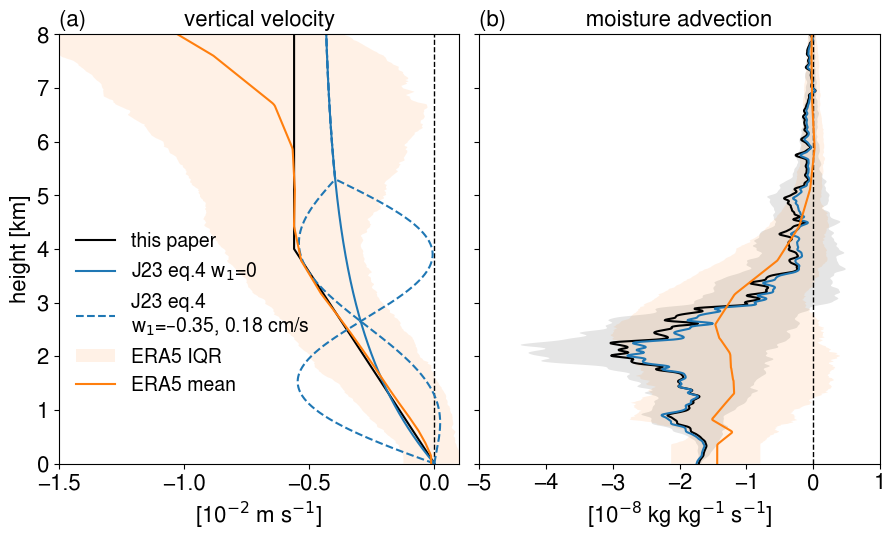

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


[None, None, None, None]

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(9, 5.5), sharey=True)

# -------------------- (1) W --------------------
ax = axs[0]
ax.axvline(0, linewidth=1, linestyle='--', color='k')
ax.plot(w_smn*1e2, z/1000, '-', color='k', label='this paper')
ax.plot(w_dales1*1e2, z/1000, '-', color='tab:blue', label='J23 eq.4 w$_1$=0')
ax.plot(w_dales[0, :]*1e2, z/1000, '--', color='tab:blue', label='J23 eq.4\nw$_1$=–0.35, 0.18 cm/s')
ax.plot(w_dales[1, :]*1e2, z/1000, '--', color='tab:blue') # label='J23 eq.4 w$_1$=0.18 cm/s')

ax.fill_betweenx(z/1000, wpt_e5z[1, :]*1e2, wpt_e5z[3, :]*1e2, color='tab:orange', alpha=0.1, edgecolor='none', label='ERA5 IQR')
# ax.fill_betweenx(z/1000, (wm_e5z-wsd_e5z)*1e2, (wm_e5z+wsd_e5z)*1e2, color='r', alpha=0.15, edgecolor='none', label='ERA5 1 STD')
ax.plot(wm_e5z*1e2, z/1000, '-', color='tab:orange', label='ERA5 mean')
# ax.plot(wpt_e5z[2, :]*1e2, z/1000, '--', color='tab:orange', label='ERA5 median')

ax.set_yticks(np.arange(0, 20, 1))
ax.set_xlim(-1.5, 0.1)
ax.set_ylim(0, 8)

ax.tick_params(axis="both", labelsize=16)

# ax.set_xlabel(r"$\omega$ (Pa s$^{-1}$)")
ax.set_xlabel("[10$^{-2}$ m s$^{-1}$]", fontsize=16)
ax.set_ylabel("height [km]", fontsize=16)
ax.set_title("(a)                vertical velocity", fontsize=16, loc='left' ) #, fontweight='bold', loc='left')

# ax.grid(linestyle='--', alpha=0.5)
ax.legend(frameon=False, fontsize=14, loc='center left', bbox_to_anchor=(0.0, 0.35))

# -------------------- (2) LS total --------------------
ax = axs[1]
ax.axvline(0, linewidth=1, linestyle='--', color='k')
# ax.fill_betweenx(z[:-1]/1000, lspt_rss[1, :], lspt_rss[3, :], color='k', alpha=0.1, edgecolor='none')
ax.fill_betweenx(z[:-1]/1000, 1e8*filt_rfv(lspt_rs_smn[1, :]), 1e8*filt_rfv(lspt_rs_smn[3, :]), color='k', alpha=0.1, edgecolor='none')
# ax.plot(lsm_rs_smn, z[:-1]/1000, 'k-', label='RonBrown-Simon')
ax.plot(1e8*filt_rfv(lsm_rs_smn), z[:-1]/1000, 'k-', label='Ron Brown (smoothed)')

# ax.fill_betweenx(z[:-1]/1000, lspt_rs_dales1[1, :], lspt_rs_dales1[3, :], color='tab:blue', alpha=0.1, edgecolor='none')
# ax.fill_betweenx(z[:-1]/1000, 1e8*filt_rfv(lspt_rs_dales1[1, :]), 1e8*filt_rfv(lspt_rs_dales1[3, :]), color='tab:blue', alpha=0.1, edgecolor='none')
# ax.plot(lsm_rs_dales1, z[:-1]/1000, '-', color='tab:blue', label='RonBrown-Hadley')
ax.plot(1e8*filt_rfv(lsm_rs_dales1), z[:-1]/1000, '-', color='tab:blue', label='RonBrown-Hadley (smoothed)')

# ax.fill_betweenx(z[:-1]/1000, lspt_rs_dales[1, 0, :], lspt_rs_dales[3, 0, :], color='tab:green', alpha=0.1, edgecolor='none')
# ax.fill_betweenx(z[:-1]/1000, filt_rfv(lspt_rs_dales[1, 0, :]), filt_rfv(lspt_rs_dales[3, 0, :]), color='tab:green', alpha=0.1, edgecolor='none')
# ax.fill_betweenx(z[:-1]/1000, filt_rfv(lspt_rs_dales[1, :]), filt_rfv(lspt_rs_dales[3, :]), color='tab:green', alpha=0.1, edgecolor='none')
# ax.plot(lsm_rs_dales[0, :], z[:-1]/1000, '-', color='tab:green', label='RonBrown-Hadley+Mesoscale')
# ax.plot(filt_rfv(lsm_rs_dales[0, :]), z[:-1]/1000, '-', color='tab:green', label='RonBrown-Hadley+Mesoscale (smoothed)')
# ax.plot(filt_rfv(lsm_rs_dales), z[:-1]/1000, '-', color='tab:green', label='RonBrown-Hadley+Mesoscale (smoothed)')
# ax.plot(lsm_rs_dales[1, :], z[:-1]/1000, '--', color='tab:green', linewidth=0.8)

ax.fill_betweenx(z/1000, 1e8*lspt_e5z[1, :], 1e8*lspt_e5z[3, :], color='tab:orange', alpha=0.1, edgecolor='none')
ax.plot(1e8*lsm_e5z, z/1000, '-', color='tab:orange', label='ERA5')

# ax.set_yticks(np.arange(0, 20, 1))
ax.set_xlim(-5, 1)
ax.set_ylim(0, 8)

ax.tick_params(axis="both", labelsize=16)

ax.set_xlabel("[10$^{-8}$ kg kg$^{-1}$ s$^{-1}$]", fontsize=16)
# ax.set_ylabel("Height [km]")
ax.set_title("(b)             moisture advection", fontsize=16, loc='left' ) #, fontweight='bold', loc='left')
# ax.legend()

# ax.grid(linestyle='--', alpha=0.5)
# ax.grid(axis='x', linestyle='-', alpha=0.5)
# ax.grid(axis='y', color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

[ fig.savefig("advection."+f) for f in ['pdf','eps','png','svg'] ]